# Histogram of mpsky processing times

Author: mjuric

Compares the processing times before and after the upgrade to return mpc_orbits records.

Drawn from log files exported using Loki. Example:

https://grafana.slac.stanford.edu/explore?schemaVersion=1&panes=%7B%220eu%22%3A%7B%22datasource%22%3A%223NYPBf44k%22%2C%22queries%22%3A%5B%7B%22refId%22%3A%22A%22%2C%22expr%22%3A%22%7Bapp%3D%5C%22mpsky%5C%22%7D+%7C%3D+%60Processing+time%60%22%2C%22queryType%22%3A%22range%22%2C%22datasource%22%3A%7B%22type%22%3A%22loki%22%2C%22uid%22%3A%223NYPBf44k%22%7D%2C%22editorMode%22%3A%22builder%22%2C%22maxLines%22%3A999999%7D%5D%2C%22range%22%3A%7B%22from%22%3A%221768593600000%22%2C%22to%22%3A%221768680000000%22%7D%2C%22panelsState%22%3A%7B%22logs%22%3A%7B%22columns%22%3A%7B%220%22%3A%22Time%22%2C%221%22%3A%22Line%22%7D%2C%22visualisationType%22%3A%22table%22%2C%22labelFieldName%22%3A%22labels%22%7D%7D%7D%7D&orgId=1

then tweak the time range, then hit 'Download' for the lines in the log.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

fn_after = "Explore-logs-2026-01-28 04_48_30.txt"    # Before mpsky upgrades to return mpc_orbits
fn_before = "Explore-logs-2026-01-28 05_14_49.txt"   # After the upgrades

def load_file(fn):
    pattern = (
        r'(?P<ts>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+).*?'
        r'Processing time (?P<dt>[0-9.]+) msec'
    )
    
    with open(fn) as fp:
        df = pd.DataFrame({"line": fp})
    
    df = df["line"].str.extract(pattern).dropna()
    df = df.assign(
            ts=lambda x: pd.to_datetime(x["ts"]),
            dt=lambda x: x["dt"].astype(float),
        )
    return df

df_before, df_after = load_file(fn_before), load_file(fn_after)

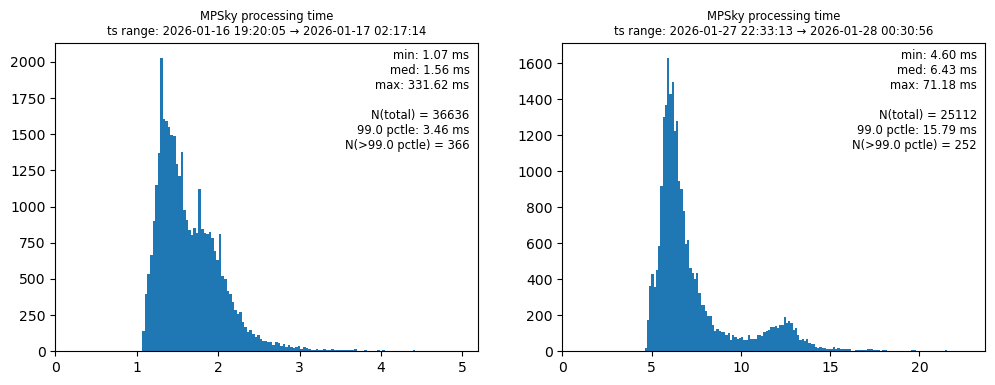

In [6]:
def draw_histogram(df, ax):
    ax.hist(df["dt"], bins="fd")

    pclim = 0.99
    pct = df["dt"].quantile(0.99)
    ax.set_xlim(0, 1.5 * pct)
    
    ts_min = df["ts"].min().strftime("%Y-%m-%d %H:%M:%S")
    ts_max = df["ts"].max().strftime("%Y-%m-%d %H:%M:%S")
    ax.set_title(
        f"MPSky processing time\n"
        f"ts range: {ts_min} → {ts_max}",
        fontsize="small",
    )
    
    stats = (
        f"min: {df['dt'].min():.2f} ms\n"
        f"med: {df['dt'].median():.2f} ms\n"
        f"max: {df['dt'].max():.2f} ms\n\n"
        f"N(total) = {len(df)}\n"
        f"{pclim*100} pctle: {pct:.2f} ms\n"
        f"N(>{pclim*100} pctle) = {len(df[df.dt > pct])}"
    )
    
    ax.text(
        0.98, 0.98, stats,
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize="small",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.8,
            edgecolor="none",
        ),
    );

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 4))
draw_histogram(df_before, ax1)
draw_histogram(df_after, ax2)

Interesting things to note:
* The outlier in the left plot (331ms) is the first query of the night. My guess is it has to do with the machine where mpsky running swapping in some of the files (they're memory mapped). May be good to investigate, I don't like latency spikes even if they appear harmles.
* The distribution is bimodal, which I /think/ (based on light spot checking) happens because when two requests come at the same time, mpsky (since it's single-threaded) queues the second thus doubling its processing time. If we had to, we could resolve this by launching multiple workers.